In [1]:
import os
import math
import time
import random
import shutil
import itertools
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from multiprocessing import Pool, cpu_count
from tqdm import tqdm, trange

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from bika import BiKA_Linear, BiKA_Conv2d

# GPU Setting

#### After decided which GPU to train, don't change it before completing the training

In [2]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [3]:
GPU_device = "cuda:1"

# Training date output folder path

#### For different network model setting, please change the name of save_path

In [4]:
save_path     = "TCV_BiKA"

project_root  = os.path.abspath(".")
dataset_root  = os.path.join(project_root, "dataset")
train_root    = os.path.join(project_root, "train")
output_root   = os.path.join(train_root, save_path)
report_root  = os.path.join(project_root, "report")

print("Dataset Download Path: ", dataset_root, "\n")
print("Training Data Output Path: ", output_root, "\n")
print("Training Report Output Path: ", report_root)

os.makedirs(dataset_root, exist_ok=True)
os.makedirs(output_root, exist_ok=True)
os.makedirs(report_root, exist_ok=True)

Dataset Download Path:  /home/yuhao/project/new KAN/BiKA/experiment/CNN-like/FashionMNIST/dataset 

Training Data Output Path:  /home/yuhao/project/new KAN/BiKA/experiment/CNN-like/FashionMNIST/train/TCV_BiKA 

Training Report Output Path:  /home/yuhao/project/new KAN/BiKA/experiment/CNN-like/FashionMNIST/report


# Hyperparameter Setups

In [5]:
epochs = 200
batch_sizes = [256, 512, 1024]
dropout_rates = [0.0]
lr_max_pool = [0.0010, 0.0005, 0.0002, 0.0001]
lr_min_pool = [0.000001]

# Network Definition

In [6]:
kernel_size=(3,3) 

in_channel_0=1
out_channel_0=256 

in_channel_1=out_channel_0
out_channel_1=256

input_length = 7*7*out_channel_1
hidden_0 = 256   

output_length = 10 

In [7]:
class TCV(nn.Module):
    def __init__(self, dropout=0.5):
        super(TCV, self).__init__()
        
        self.conv0 = BiKA_Conv2d( 
                         in_channels=in_channel_0,
                         out_channels=out_channel_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1
                     )
        self.drop0 = nn.Dropout(dropout)
        self.pool0 = nn.MaxPool2d(2)
        
        self.conv1 = BiKA_Conv2d( 
                         in_channels=in_channel_1,
                         out_channels=out_channel_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1
                     )
        self.drop1 = nn.Dropout(dropout)
        self.pool1 = nn.MaxPool2d(2)
        
        self.fc2   = BiKA_Linear(
                         input_length, 
                         hidden_0
                     )
        self.drop2 = nn.Dropout(dropout)
        
        self.out   = BiKA_Linear(
                         hidden_0, 
                         output_length
                     )

    def forward(self, x):
        out = self.pool0(self.drop0(self.conv0(x)))
        out = self.pool1(self.drop1(self.conv1(out)))
        out = out.reshape(out.shape[0], -1)
        out = self.drop2(self.fc2(out))
        out = self.out(out)
        return out

# Random Seed Utility

In [8]:
def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Define Dataloader

In [9]:
test_batch_size = 4096

In [10]:
def get_dataloaders(batch_size):    
    train_dataset = datasets.FashionMNIST(  dataset_root, 
                                     train=True, 
                                     download=True,
                                     transform=transforms.Compose
                                     ([
                                         transforms.ToTensor(),
                                         transforms.Normalize((0.5,), (0.5,))
                                     ])
                                  )
    test_dataset  = datasets.FashionMNIST( dataset_root, 
                                    train=False, 
                                    download=True,
                                    transform=transforms.Compose
                                    ([
                                         transforms.ToTensor(),
                                         transforms.Normalize((0.5,), (0.5,))
                                    ])
                                  )
    val_size = int(0.2 * len(train_dataset))
    train_size = len(train_dataset) - val_size
    train_set, val_set = random_split(train_dataset, [train_size, val_size])
    return (
        DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            num_workers=12,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(
            val_set,
            batch_size=batch_size,
            shuffle=False,
            num_workers=12,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(test_dataset, batch_size=test_batch_size),
    )

# Evaluation Pipeline

In [11]:
def evaluate(model, criterion, device, loader, show_progress=False):
    model.eval()
    loss_total, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Evaluation", leave=True, disable=not show_progress):
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            loss_total += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += (pred == y).sum().item()
            total += x.size(0)

    return loss_total / total, correct / total

# Plot Training Loss and Accuracy

In [12]:
def plot_train(history, save_dir):
    # Plot and show
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_plot.png"))
    plt.show()

# Training, Validation, and Testing Pipeline

In [13]:
def train_validate_test(config, save_dir):
    set_random_seed()
    os.makedirs(save_dir, exist_ok=True)
    log_file = os.path.join(save_dir, "training_log.txt")
    resume_path = os.path.join(save_dir, "checkpoint.pth")
    csv_log_path = os.path.join(save_dir, "training_log.csv")
    with open(csv_log_path, "a") as f:
        if os.path.getsize(csv_log_path) == 0:
            f.write("Epoch,Learning Rate,Train Loss,Train Acc,Val Loss,Val Acc,Epoch Time,Train Time,Val Time\n")

    epochs, batch_size, lr_max, lr_min, dropout = config
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = TCV(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_max)

    start_epoch = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "epoch_time": [], "train_time": [], "val_time": []}

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path, map_location="cpu")
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        for state in optimizer.state.values():
            for k, v in state.items():
                if torch.is_tensor(v):
                    state[k] = v.to(device)
        history = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"🔄 Resuming from epoch {start_epoch}")
    else:
        with open(log_file, "w") as f:
            f.write("Training started\n")

    # Training Loop
    t = trange(start_epoch, epochs, desc="Training", leave=True)
    for epoch in t:
        epoch_start = time.time()
        model.train()
        lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * epoch / epochs))
        for g in optimizer.param_groups:
            g["lr"] = lr

        train_start = time.time()
        train_loss, correct, total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += (pred == y).sum().item()
            total += x.size(0)
        train_time = time.time() - train_start

        val_start = time.time()
        val_loss, val_acc = evaluate(model, criterion, device, val_loader)
        val_time = time.time() - val_start
        train_loss /= total
        train_acc = correct / total
        epoch_time = time.time() - epoch_start
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time/60)
        history["train_time"].append(train_time/60)
        history["val_time"].append(val_time/60)

        log_line = (f"Epoch {epoch+1}/{epochs} - LR: {lr:.6f} | "
                    f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                    f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
                    f"Epoch Time: {epoch_time/60:.2f}, Train Time: {train_time/60:.2f}, Val Time: {val_time/60:.2f}")
        
        with open(log_file, "a") as f:
            f.write(log_line + "\n")

        
        with open(os.path.join(save_dir, "training_log.csv"), "a") as f:
            f.write(f"{epoch+1},{lr:.6f},{train_loss:.4f},{train_acc:.4f},{val_loss:.4f},{val_acc:.4f},{epoch_time/60:.4f},{train_time/60:.4f},{val_time/60:.4f}\n")

        t.set_description("| LR: %.6f | Train Acc: %.4f | Val Acc: %.4f | Epoch Time: %.2f | " % (lr, train_acc, val_acc, epoch_time/60))
        t.refresh()

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }, resume_path)

    # Plot and show the training history
    plot_train(history, save_dir)

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader)
    final_line = f"Original Model Final Test Loss: {original_test_loss:.4f} Accuracy: {original_test_acc:.4f}"
    print(final_line)
    with open(log_file, "a") as f:
        f.write("Training completed\n")
        f.write(final_line + "\n")

    # Save the trained model
    torch.save(model.state_dict(), os.path.join(save_dir, "final_model.pth"))
    with open(log_file, "a") as f:
        f.write(final_line + "\n")
    print("\n")

    return original_test_acc, resume_path

# Hyperparameter Searching for Network Training and Testing

In [14]:
def Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
    
    epochs = epochs
    batch_sizes = batch_sizes
    lr_max_pool = lr_max_pool
    lr_min_pool = lr_min_pool
    
    all_runs = [
        f"batch{bs}_lr_max_{lr_max}_min_{lr_min}_dp{dropout}"
        for bs, lr_max, lr_min, dropout in itertools.product(batch_sizes, lr_max_pool, lr_min_pool, dropout_rates)
    ]
    
    completed_runs = []
    for run in all_runs:
        log_path = os.path.join(output_root, run, "training_log.txt")
        if os.path.exists(log_path):
            with open(log_path, "r") as f:
                if any("Training completed" in line for line in f):
                    completed_runs.append(run)
    
    if len(completed_runs) == len(all_runs):
        print("✅ All combinations completed. Restarting from scratch...")
        for run in all_runs:
            shutil.rmtree(os.path.join(output_root, run), ignore_errors=True)
        if os.path.exists(os.path.join(report_root, save_path+"_report.csv")):
            os.remove(os.path.join(report_root, save_path+"_report.csv"))
        completed_runs = []
    
    results = []
    for batch_size, lr_max, lr_min, dropout in itertools.product(batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
        run_name = f"batch{batch_size}_lr_max_{lr_max}_min_{lr_min}_dp{dropout}"
        save_dir = os.path.join(output_root, run_name)
    
        if run_name in completed_runs:
            print(f"✅ Skipping {run_name}")
            with open(os.path.join(save_dir, "training_log.txt")) as f:
                for line in f:
                    if "Final Test Loss" in line:
                        acc = float(line.strip().split()[-1])
                        results.append((run_name, acc))
            continue
    
        print(f"🚀 Running: {run_name}")
        acc, resume_path = train_validate_test([epochs, batch_size, lr_max, lr_min, dropout], save_dir)
        results.append((run_name, acc, epochs, batch_size, lr_max, lr_min, dropout, resume_path))
    
    results.sort(key=lambda x: x[1], reverse=True)
    best_config, best_acc, best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path = results[0]
    
    with open(os.path.join(report_root, save_path+"_report.csv"), "w") as f:
        f.write("Epoch,Batch Size,LR_max,LR_min,Dropout,Accuracy\n")
        for name, acc, epoch, batch_size, lr_max, lr_min, dropout, resume_path in results:
            f.write(f"{epoch},{batch_size},{lr_max:.4f},{lr_min:.6f},{dropout:.4f},{acc:.4f}\n")
            
    return best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path

In [15]:
def best_evaluation(epochs, batch_size, lr_max, lr_min, dropout, resume_path):
    set_random_seed()

    epochs, batch_size, lr_max, lr_min, dropout = epochs, batch_size, lr_max, lr_min, dropout
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = TCV(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_max)

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path, map_location="cpu")
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        for state in optimizer.state.values():
            for k, v in state.items():
                if torch.is_tensor(v):
                    state[k] = v.to(device)
        history = ckpt["history"]
        print("Best model loaded.")
    else:
        print("Best model lost.")

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader, show_progress=True)
    final_line = (
        f"Best Original Model Final Test Loss: {original_test_loss:.4f} "
        f"Acc: {original_test_acc:.4f} "
    )
    print(final_line)
    print("\n")

    with open(os.path.join(report_root, save_path + "_best_eval.csv"), "w") as f:
        f.write("Epoch,Batch Size,LR_max,LR_min,Dropout,Acc,Loss\n")
        f.write(f"{epochs},{batch_size},{lr_max:.4f},{lr_min:.6f},{dropout:.4f},{original_test_acc:.4f},{original_test_loss:.4f}\n")

✅ All combinations completed. Restarting from scratch...


🚀 Running: batch256_lr_max_0.001_min_1e-06_dp0.0


Training:   0%|                                                                                                                                        | 0/200 [00:00<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.5833 | Val Acc: 0.6758 | Epoch Time: 1.69 | :   0%|                                                                      | 0/200 [01:41<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.5833 | Val Acc: 0.6758 | Epoch Time: 1.69 | :   0%|                                                                      | 0/200 [01:41<?, ?it/s]

...

| LR: 0.000001 | Train Acc: 0.9497 | Val Acc: 0.8491 | Epoch Time: 1.68 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:34:19<01:40, 100.96s/it]

| LR: 0.000001 | Train Acc: 0.9476 | Val Acc: 0.8476 | Epoch Time: 1.68 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:35:59<01:40, 100.96s/it]

| LR: 0.000001 | Train Acc: 0.9476 | Val Acc: 0.8476 | Epoch Time: 1.68 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:35:59<01:40, 100.96s/it]

| LR: 0.000001 | Train Acc: 0.9476 | Val Acc: 0.8476 | Epoch Time: 1.68 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:36:00<00:00, 100.96s/it]

| LR: 0.000001 | Train Acc: 0.9476 | Val Acc: 0.8476 | Epoch Time: 1.68 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:36:00<00:00, 100.80s/it]

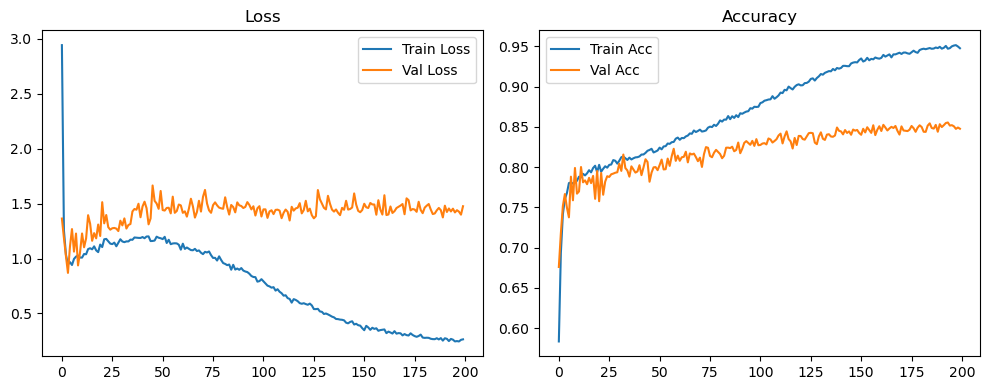

Original Model Final Test Loss: 1.5435 Accuracy: 0.8466


🚀 Running: batch256_lr_max_0.0005_min_1e-06_dp0.0


Training:   0%|                                                                                                                                        | 0/200 [00:00<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.6187 | Val Acc: 0.6624 | Epoch Time: 1.70 | :   0%|                                                                      | 0/200 [01:41<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.6187 | Val Acc: 0.6624 | Epoch Time: 1.70 | :   0%|                                                                      | 0/200 [01:41<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.6187 | Val Acc: 0.6624 | Epoch Time: 1.70 | :   0%|▎                                                          | 1/200 [01:41<5:38:04, 101.93s/it]

...

| LR: 0.000001 | Train Acc: 0.9788 | Val Acc: 0.8734 | Epoch Time: 1.68 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:35:01<01:41, 101.08s/it]

| LR: 0.000001 | Train Acc: 0.9784 | Val Acc: 0.8698 | Epoch Time: 1.68 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:36:42<01:41, 101.08s/it]

| LR: 0.000001 | Train Acc: 0.9784 | Val Acc: 0.8698 | Epoch Time: 1.68 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:36:42<01:41, 101.08s/it]

| LR: 0.000001 | Train Acc: 0.9784 | Val Acc: 0.8698 | Epoch Time: 1.68 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:36:42<00:00, 101.08s/it]

| LR: 0.000001 | Train Acc: 0.9784 | Val Acc: 0.8698 | Epoch Time: 1.68 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:36:42<00:00, 101.01s/it]

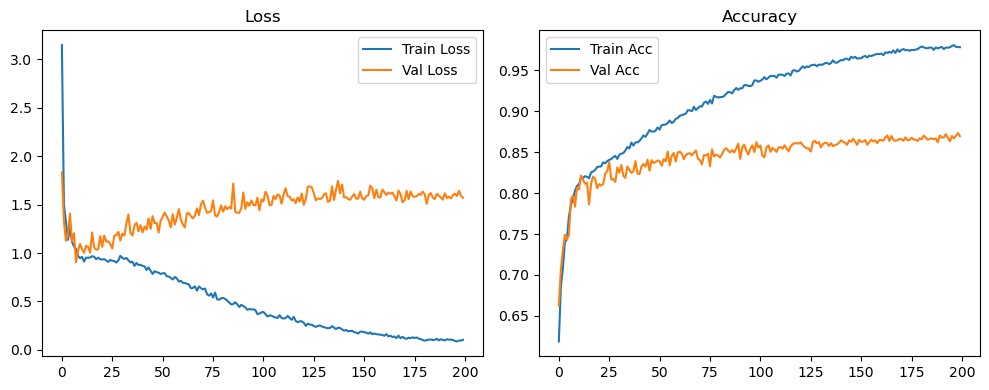

Original Model Final Test Loss: 1.7498 Accuracy: 0.8583


🚀 Running: batch256_lr_max_0.0002_min_1e-06_dp0.0


Training:   0%|                                                                                                                                        | 0/200 [00:00<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.6502 | Val Acc: 0.7084 | Epoch Time: 1.70 | :   0%|                                                                      | 0/200 [01:41<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.6502 | Val Acc: 0.7084 | Epoch Time: 1.70 | :   0%|                                                                      | 0/200 [01:41<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.6502 | Val Acc: 0.7084 | Epoch Time: 1.70 | :   0%|▎                                                          | 1/200 [01:41<5:37:40, 101.81s/it]

...

| LR: 0.000001 | Train Acc: 0.9811 | Val Acc: 0.8845 | Epoch Time: 1.68 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:35:31<01:41, 101.16s/it]

| LR: 0.000001 | Train Acc: 0.9788 | Val Acc: 0.8805 | Epoch Time: 1.68 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:37:12<01:41, 101.16s/it]

| LR: 0.000001 | Train Acc: 0.9788 | Val Acc: 0.8805 | Epoch Time: 1.68 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:37:12<01:41, 101.16s/it]

| LR: 0.000001 | Train Acc: 0.9788 | Val Acc: 0.8805 | Epoch Time: 1.68 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:37:12<00:00, 101.16s/it]

| LR: 0.000001 | Train Acc: 0.9788 | Val Acc: 0.8805 | Epoch Time: 1.68 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:37:12<00:00, 101.16s/it]

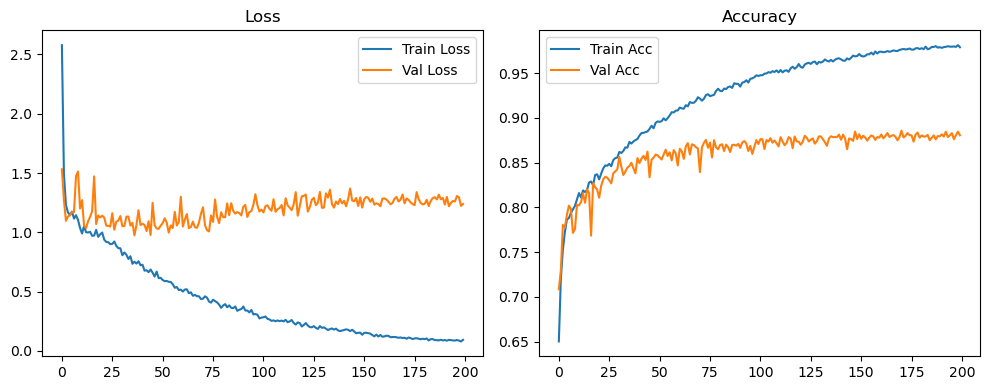

Original Model Final Test Loss: 1.3474 Accuracy: 0.8764


🚀 Running: batch256_lr_max_0.0001_min_1e-06_dp0.0


Training:   0%|                                                                                                                                        | 0/200 [00:00<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.6595 | Val Acc: 0.7213 | Epoch Time: 1.70 | :   0%|                                                                      | 0/200 [01:41<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.6595 | Val Acc: 0.7213 | Epoch Time: 1.70 | :   0%|                                                                      | 0/200 [01:41<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.6595 | Val Acc: 0.7213 | Epoch Time: 1.70 | :   0%|▎                                                          | 1/200 [01:41<5:37:59, 101.91s/it]

...

| LR: 0.000001 | Train Acc: 0.9886 | Val Acc: 0.8835 | Epoch Time: 1.68 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:35:28<01:41, 101.08s/it]

| LR: 0.000001 | Train Acc: 0.9886 | Val Acc: 0.8801 | Epoch Time: 1.68 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:37:09<01:41, 101.08s/it]

| LR: 0.000001 | Train Acc: 0.9886 | Val Acc: 0.8801 | Epoch Time: 1.68 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:37:09<01:41, 101.08s/it]

| LR: 0.000001 | Train Acc: 0.9886 | Val Acc: 0.8801 | Epoch Time: 1.68 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:37:09<00:00, 101.07s/it]

| LR: 0.000001 | Train Acc: 0.9886 | Val Acc: 0.8801 | Epoch Time: 1.68 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:37:09<00:00, 101.15s/it]

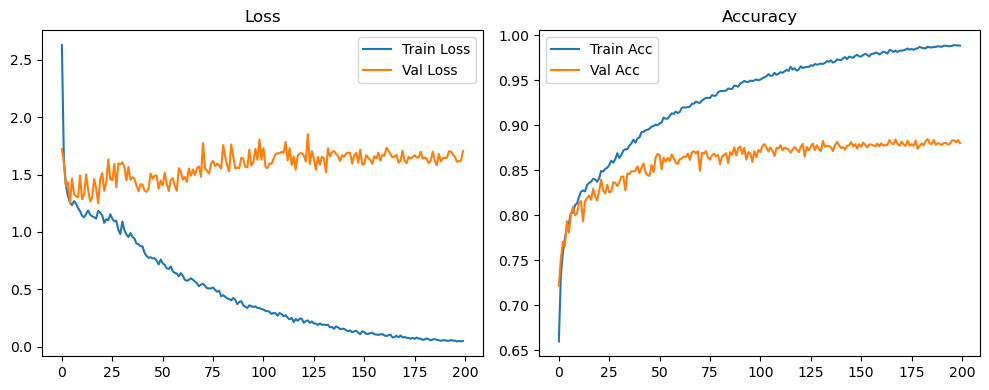

Original Model Final Test Loss: 1.9104 Accuracy: 0.8732


🚀 Running: batch512_lr_max_0.001_min_1e-06_dp0.0


Training:   0%|                                                                                                                                        | 0/200 [00:00<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.5815 | Val Acc: 0.6460 | Epoch Time: 1.70 | :   0%|                                                                      | 0/200 [01:42<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.5815 | Val Acc: 0.6460 | Epoch Time: 1.70 | :   0%|                                                                      | 0/200 [01:42<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.5815 | Val Acc: 0.6460 | Epoch Time: 1.70 | :   0%|▎                                                          | 1/200 [01:42<5:39:28, 102.36s/it]

...

| LR: 0.000001 | Train Acc: 0.9691 | Val Acc: 0.8542 | Epoch Time: 1.69 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:36:44<01:41, 101.71s/it]

| LR: 0.000001 | Train Acc: 0.9691 | Val Acc: 0.8495 | Epoch Time: 1.69 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:38:25<01:41, 101.71s/it]

| LR: 0.000001 | Train Acc: 0.9691 | Val Acc: 0.8495 | Epoch Time: 1.69 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:38:25<01:41, 101.71s/it]

| LR: 0.000001 | Train Acc: 0.9691 | Val Acc: 0.8495 | Epoch Time: 1.69 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:38:25<00:00, 101.71s/it]

| LR: 0.000001 | Train Acc: 0.9691 | Val Acc: 0.8495 | Epoch Time: 1.69 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:38:25<00:00, 101.53s/it]

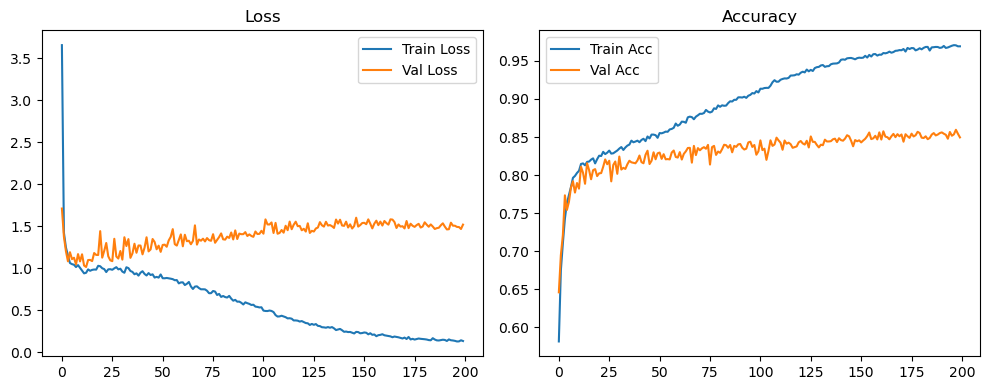

Original Model Final Test Loss: 1.5924 Accuracy: 0.8508


🚀 Running: batch512_lr_max_0.0005_min_1e-06_dp0.0


Training:   0%|                                                                                                                                        | 0/200 [00:00<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.6069 | Val Acc: 0.6676 | Epoch Time: 1.70 | :   0%|                                                                      | 0/200 [01:42<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.6069 | Val Acc: 0.6676 | Epoch Time: 1.70 | :   0%|                                                                      | 0/200 [01:42<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.6069 | Val Acc: 0.6676 | Epoch Time: 1.70 | :   0%|▎                                                          | 1/200 [01:42<5:39:22, 102.32s/it]

...

| LR: 0.000001 | Train Acc: 0.9779 | Val Acc: 0.8739 | Epoch Time: 1.70 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:37:28<01:41, 101.80s/it]

| LR: 0.000001 | Train Acc: 0.9767 | Val Acc: 0.8815 | Epoch Time: 1.70 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:39:09<01:41, 101.80s/it]

| LR: 0.000001 | Train Acc: 0.9767 | Val Acc: 0.8815 | Epoch Time: 1.70 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:39:09<01:41, 101.80s/it]

| LR: 0.000001 | Train Acc: 0.9767 | Val Acc: 0.8815 | Epoch Time: 1.70 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:39:09<00:00, 101.80s/it]

| LR: 0.000001 | Train Acc: 0.9767 | Val Acc: 0.8815 | Epoch Time: 1.70 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:39:09<00:00, 101.75s/it]

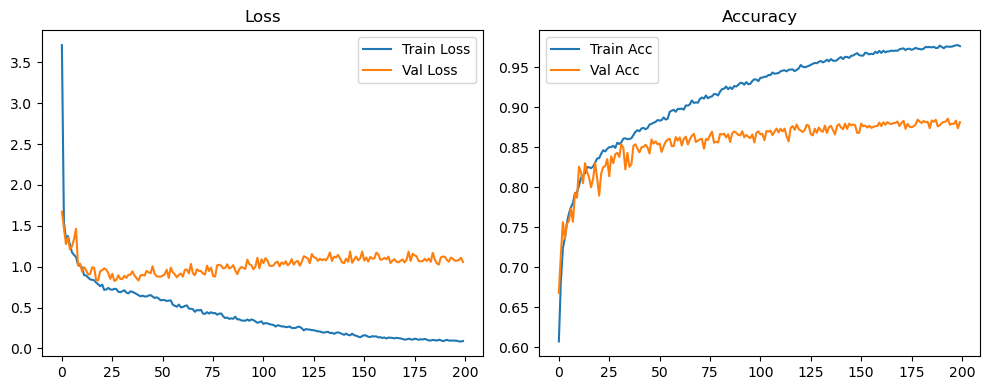

Original Model Final Test Loss: 1.1733 Accuracy: 0.8747


🚀 Running: batch512_lr_max_0.0002_min_1e-06_dp0.0


Training:   0%|                                                                                                                                        | 0/200 [00:00<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.6234 | Val Acc: 0.6930 | Epoch Time: 1.71 | :   0%|                                                                      | 0/200 [01:42<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.6234 | Val Acc: 0.6930 | Epoch Time: 1.71 | :   0%|                                                                      | 0/200 [01:42<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.6234 | Val Acc: 0.6930 | Epoch Time: 1.71 | :   0%|▎                                                          | 1/200 [01:42<5:40:04, 102.53s/it]

...

| LR: 0.000001 | Train Acc: 0.9805 | Val Acc: 0.8839 | Epoch Time: 1.69 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:37:29<01:41, 101.74s/it]

| LR: 0.000001 | Train Acc: 0.9825 | Val Acc: 0.8824 | Epoch Time: 1.69 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:39:10<01:41, 101.74s/it]

| LR: 0.000001 | Train Acc: 0.9825 | Val Acc: 0.8824 | Epoch Time: 1.69 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:39:10<01:41, 101.74s/it]

| LR: 0.000001 | Train Acc: 0.9825 | Val Acc: 0.8824 | Epoch Time: 1.69 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:39:11<00:00, 101.74s/it]

| LR: 0.000001 | Train Acc: 0.9825 | Val Acc: 0.8824 | Epoch Time: 1.69 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:39:11<00:00, 101.76s/it]

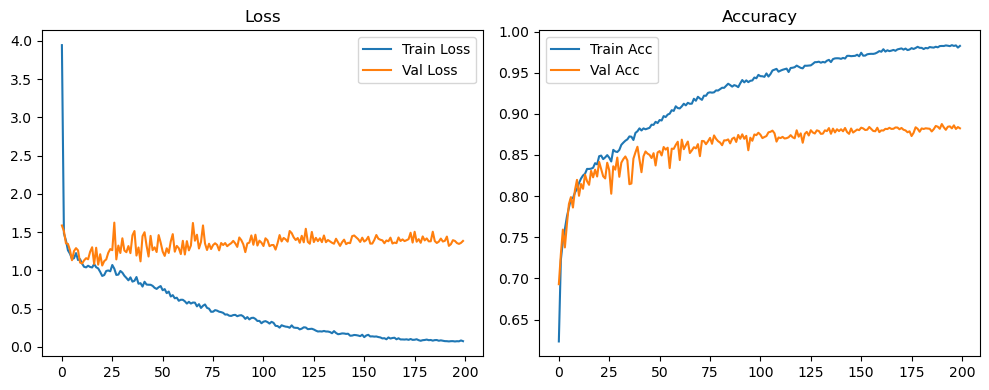

Original Model Final Test Loss: 1.5626 Accuracy: 0.8731


🚀 Running: batch512_lr_max_0.0001_min_1e-06_dp0.0


Training:   0%|                                                                                                                                        | 0/200 [00:00<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.6330 | Val Acc: 0.6977 | Epoch Time: 1.71 | :   0%|                                                                      | 0/200 [01:42<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.6330 | Val Acc: 0.6977 | Epoch Time: 1.71 | :   0%|                                                                      | 0/200 [01:42<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.6330 | Val Acc: 0.6977 | Epoch Time: 1.71 | :   0%|▎                                                          | 1/200 [01:42<5:40:11, 102.57s/it]

...

| LR: 0.000001 | Train Acc: 0.9873 | Val Acc: 0.8799 | Epoch Time: 1.70 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:37:30<01:41, 101.79s/it]

| LR: 0.000001 | Train Acc: 0.9876 | Val Acc: 0.8805 | Epoch Time: 1.69 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:39:11<01:41, 101.79s/it]

| LR: 0.000001 | Train Acc: 0.9876 | Val Acc: 0.8805 | Epoch Time: 1.69 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:39:11<01:41, 101.79s/it]

| LR: 0.000001 | Train Acc: 0.9876 | Val Acc: 0.8805 | Epoch Time: 1.69 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:39:12<00:00, 101.78s/it]

| LR: 0.000001 | Train Acc: 0.9876 | Val Acc: 0.8805 | Epoch Time: 1.69 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:39:12<00:00, 101.76s/it]

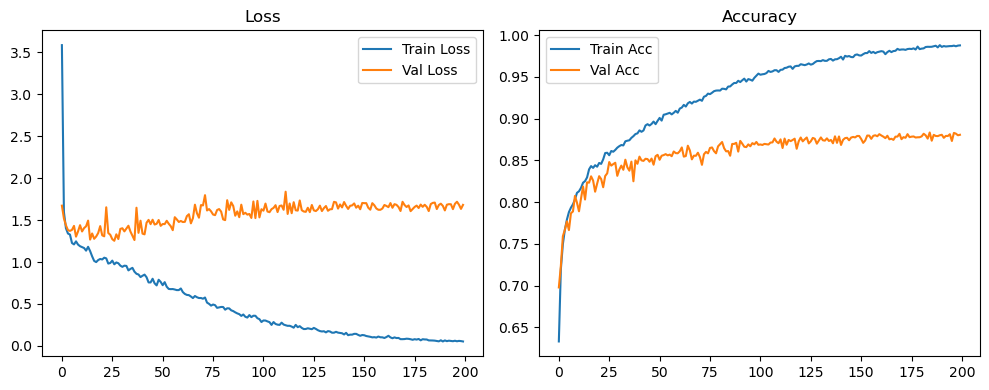

Original Model Final Test Loss: 1.7741 Accuracy: 0.8767


🚀 Running: batch1024_lr_max_0.001_min_1e-06_dp0.0


Training:   0%|                                                                                                                                        | 0/200 [00:00<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.5430 | Val Acc: 0.6253 | Epoch Time: 1.72 | :   0%|                                                                      | 0/200 [01:43<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.5430 | Val Acc: 0.6253 | Epoch Time: 1.72 | :   0%|                                                                      | 0/200 [01:43<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.5430 | Val Acc: 0.6253 | Epoch Time: 1.72 | :   0%|▎                                                          | 1/200 [01:43<5:43:02, 103.43s/it]

...

| LR: 0.000001 | Train Acc: 0.9831 | Val Acc: 0.8718 | Epoch Time: 1.71 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:40:02<01:42, 102.57s/it]

| LR: 0.000001 | Train Acc: 0.9828 | Val Acc: 0.8691 | Epoch Time: 1.71 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:41:45<01:42, 102.57s/it]

| LR: 0.000001 | Train Acc: 0.9828 | Val Acc: 0.8691 | Epoch Time: 1.71 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:41:45<01:42, 102.57s/it]

| LR: 0.000001 | Train Acc: 0.9828 | Val Acc: 0.8691 | Epoch Time: 1.71 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:41:45<00:00, 102.56s/it]

| LR: 0.000001 | Train Acc: 0.9828 | Val Acc: 0.8691 | Epoch Time: 1.71 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:41:45<00:00, 102.53s/it]

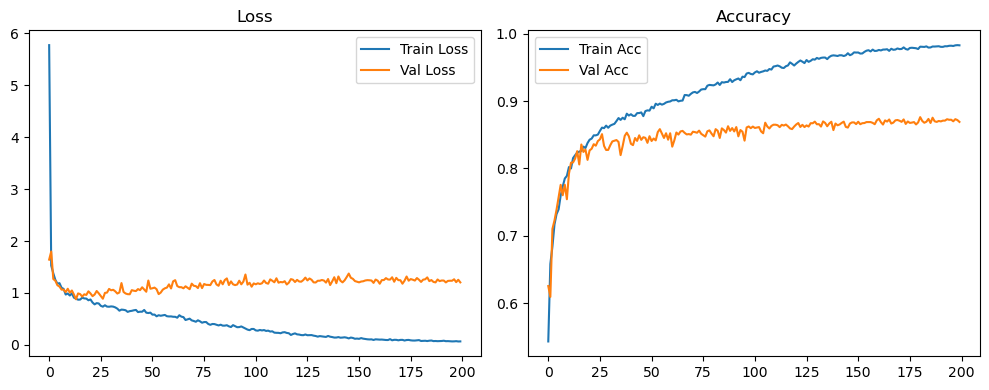

Original Model Final Test Loss: 1.3503 Accuracy: 0.8641


🚀 Running: batch1024_lr_max_0.0005_min_1e-06_dp0.0


Training:   0%|                                                                                                                                        | 0/200 [00:00<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.5667 | Val Acc: 0.6555 | Epoch Time: 1.72 | :   0%|                                                                      | 0/200 [01:43<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.5667 | Val Acc: 0.6555 | Epoch Time: 1.72 | :   0%|                                                                      | 0/200 [01:43<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.5667 | Val Acc: 0.6555 | Epoch Time: 1.72 | :   0%|▎                                                          | 1/200 [01:43<5:42:49, 103.36s/it]

...

| LR: 0.000001 | Train Acc: 0.9745 | Val Acc: 0.8851 | Epoch Time: 1.71 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:40:18<01:42, 102.65s/it]

| LR: 0.000001 | Train Acc: 0.9764 | Val Acc: 0.8837 | Epoch Time: 1.71 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:42:01<01:42, 102.65s/it]

| LR: 0.000001 | Train Acc: 0.9764 | Val Acc: 0.8837 | Epoch Time: 1.71 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:42:01<01:42, 102.65s/it]

| LR: 0.000001 | Train Acc: 0.9764 | Val Acc: 0.8837 | Epoch Time: 1.71 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:42:01<00:00, 102.65s/it]

| LR: 0.000001 | Train Acc: 0.9764 | Val Acc: 0.8837 | Epoch Time: 1.71 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:42:01<00:00, 102.61s/it]

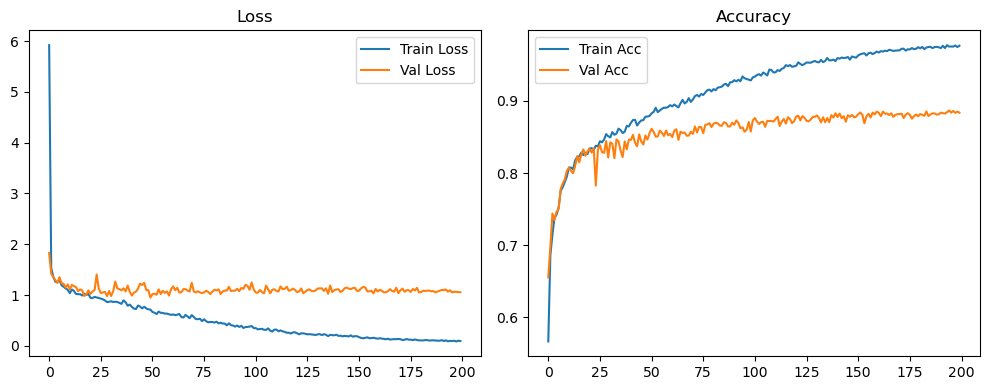

Original Model Final Test Loss: 1.1523 Accuracy: 0.8772


🚀 Running: batch1024_lr_max_0.0002_min_1e-06_dp0.0


Training:   0%|                                                                                                                                        | 0/200 [00:00<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.6047 | Val Acc: 0.6686 | Epoch Time: 1.72 | :   0%|                                                                      | 0/200 [01:43<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.6047 | Val Acc: 0.6686 | Epoch Time: 1.72 | :   0%|                                                                      | 0/200 [01:43<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.6047 | Val Acc: 0.6686 | Epoch Time: 1.72 | :   0%|▎                                                          | 1/200 [01:43<5:42:27, 103.26s/it]

...

| LR: 0.000001 | Train Acc: 0.9852 | Val Acc: 0.8802 | Epoch Time: 1.71 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:40:20<01:42, 102.61s/it]

| LR: 0.000001 | Train Acc: 0.9871 | Val Acc: 0.8802 | Epoch Time: 1.71 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:42:02<01:42, 102.61s/it]

| LR: 0.000001 | Train Acc: 0.9871 | Val Acc: 0.8802 | Epoch Time: 1.71 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:42:02<01:42, 102.61s/it]

| LR: 0.000001 | Train Acc: 0.9871 | Val Acc: 0.8802 | Epoch Time: 1.71 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:42:02<00:00, 102.60s/it]

| LR: 0.000001 | Train Acc: 0.9871 | Val Acc: 0.8802 | Epoch Time: 1.71 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:42:02<00:00, 102.61s/it]

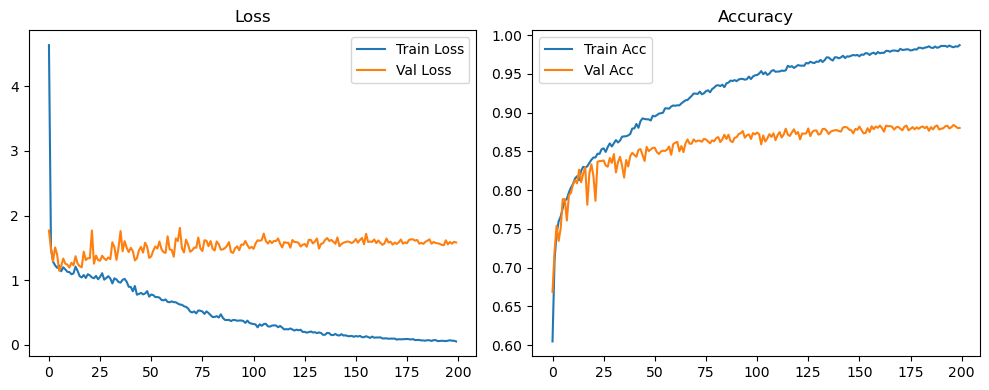

Original Model Final Test Loss: 1.6987 Accuracy: 0.8713




🚀 Running: batch1024_lr_max_0.0001_min_1e-06_dp0.0


Training:   0%|                                                                                                                                        | 0/200 [00:00<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.6076 | Val Acc: 0.7010 | Epoch Time: 1.72 | :   0%|                                                                      | 0/200 [01:43<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.6076 | Val Acc: 0.7010 | Epoch Time: 1.72 | :   0%|                                                                      | 0/200 [01:43<?, ?it/s]

...

| LR: 0.000001 | Train Acc: 0.9807 | Val Acc: 0.8827 | Epoch Time: 1.71 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:40:13<01:42, 102.59s/it]

| LR: 0.000001 | Train Acc: 0.9799 | Val Acc: 0.8767 | Epoch Time: 1.71 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:41:56<01:42, 102.59s/it]

| LR: 0.000001 | Train Acc: 0.9799 | Val Acc: 0.8767 | Epoch Time: 1.71 | : 100%|████████████████████████████████████████████████████████▋| 199/200 [5:41:56<01:42, 102.59s/it]

| LR: 0.000001 | Train Acc: 0.9799 | Val Acc: 0.8767 | Epoch Time: 1.71 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:41:56<00:00, 102.60s/it]

| LR: 0.000001 | Train Acc: 0.9799 | Val Acc: 0.8767 | Epoch Time: 1.71 | : 100%|█████████████████████████████████████████████████████████| 200/200 [5:41:56<00:00, 102.58s/it]

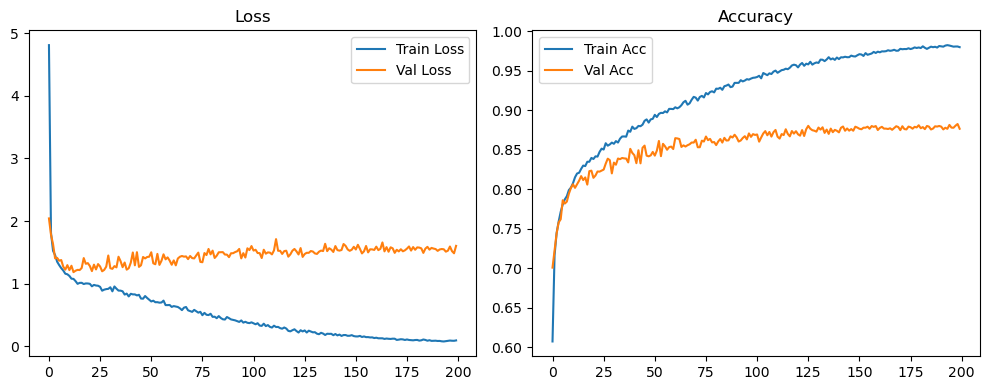

Original Model Final Test Loss: 1.7699 Accuracy: 0.8648




In [16]:
best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path  = Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates)

In [17]:
best_evaluation(best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path)

Best model loaded.


Evaluation:   0%|                                                                                                                                        | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|██████████████████████████████████████████▋                                                                                     | 1/3 [00:01<00:03,  1.85s/it]

Evaluation:  67%|█████████████████████████████████████████████████████████████████████████████████████▎                                          | 2/3 [00:03<00:01,  1.84s/it]

Evaluation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:04<00:00,  1.36s/it]

Evaluation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:04<00:00,  1.49s/it]

Best Original Model Final Test Loss: 1.1523 Acc: 0.8772 


